___

# <font color= #99C8F5> **Autoencoder for CIFAR-10 Generation** </font>
#### <font color= #2E9AFE> `Deep Learning`</font>
<Strong> Sofía Maldonado, Óscar Josué Rocha & Viviana Toledo </Strong>

_17/02/2026._

___

# <font color= #99C8F5> **Introduction** </font>

Autoencoders are a type of neural network made up of two parts: first, an **encoder** that encodes input data down to a compressed, lower-dimention representation (***latent space***). Then, a **decoder** reconstructs the input back to its original form, in the best way it can.

This arquitecture makes autoencoders very useful for image generation purposes: if an encoder can learn to represent a type of data (text, images, or anything else) in a small space, that space can be used to generate new samples based on that information, mimiquing what the training data contained.

In this exercise, we are using the CIFAR-10 dataset [1] to train a full autoencoder network that can generate images in the dataset's 10 classes. These classes are:
- Airplanes
- Cars
- Birds
- Cats
- Deer
- Dogs
- Frogs
- Horses
- Ships
- Trucks

---

In [1]:
# General
import numpy as np
import pandas as pd
from keras.datasets import cifar10

# Visualization
import matplotlib.pyplot as plt

# Models
import tensorflow as tf
from tensorflow.python.client import device_lib
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from keras.optimizers import Adam
from keras import Model

In [2]:
# Load Data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

In [3]:
# Load Data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

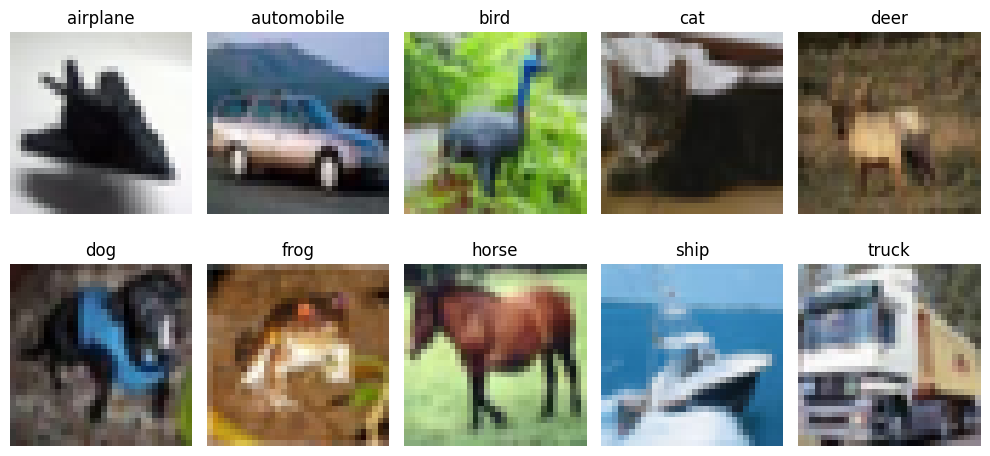

In [4]:
# Flatten labels for visualization
y_train = y_train.flatten()

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Create the plot
plt.figure(figsize=(10, 5))
# Select an image for each class
for class_id in range(10):
    index = np.where(y_train == class_id)[0][0]
    # Plot the imaage
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(X_train[index])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.tight_layout()
plt.show()

# <font color= #99C8F5> **Preprocessing** </font>

The objective of this activity is to build an autoencoder capable of recreating images of the CIFAR-10 dataset. For this reason, data-augmentation techniques would be ill-advised, since the learning and comparison between images would be hindered. Thus, only a normalization will be applied.

In [5]:
# Normalization
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

In [6]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [7]:
X_train.min(), X_train.max()

(np.float32(0.0), np.float32(1.0))

# <font color= #99C8F5> **Modeling** </font>

The model architecture will mimic a Convolutional Autoencoder with three levels of compression:

$$
1024_{input}  \rightarrow 256_{h_1} \rightarrow 128_{h_2} \rightarrow 64_{h_3} \rightarrow 32_z \leftarrow 64_{h_3} \leftarrow 128_{h_2} \leftarrow 256_{h_1} \leftarrow 1024_{output}
$$

The construction of the neural network using Keras was made based on articles [2] and [3] (check references below)

In [8]:
num_labels = 10
input_shape = (32,32,3) #1024

In [31]:
model = Sequential(name='Convolutional_AE')

# Encoder
model.add(Conv2D(256, input_shape=input_shape ,kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(1,2)))

model.add(Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,1)))

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(1,2)))

# Decoder
model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(1,2)))

model.add(Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(2,1)))

model.add(Conv2D(128, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(1,2)))

model.add(Conv2D(256, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(2,2)))

model.add(Conv2D(3, kernel_size=3, activation='sigmoid', padding='same'))

model.summary()

Model: "Convolutional_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 256)    │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 8, 64)      │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 16, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_14 (UpSampling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_15 (UpSampling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 3)      │         6,915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 798,147 (3.04 MB)

 Trainable params: 798,147 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse'
)

In [33]:
model.fit(X_train, X_train, batch_size=256, epochs=10, validation_data=(X_test, X_test))

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - loss: 0.0355 - val_loss: 0.0134
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - loss: 0.0111 - val_loss: 0.0086
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - loss: 0.0084 - val_loss: 0.0070
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - loss: 0.0074 - val_loss: 0.0063
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - loss: 0.0064 - val_loss: 0.0057
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - loss: 0.0056 - val_loss: 0.0051
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - loss: 0.0052 - val_loss: 0.0046
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - loss: 0.0049 - val_loss: 0.0042
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - loss: 0.0044 - val_loss: 0.0038


In [34]:
preds = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [35]:
preds.min(), preds.max()

(np.float32(0.0014821506), np.float32(0.99937785))

In [36]:
def display(array1, array2):
    """Displays ten random images from each array."""
    n = 10
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]

    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1.reshape(32, 32, 3))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2.reshape(32, 32, 3))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()


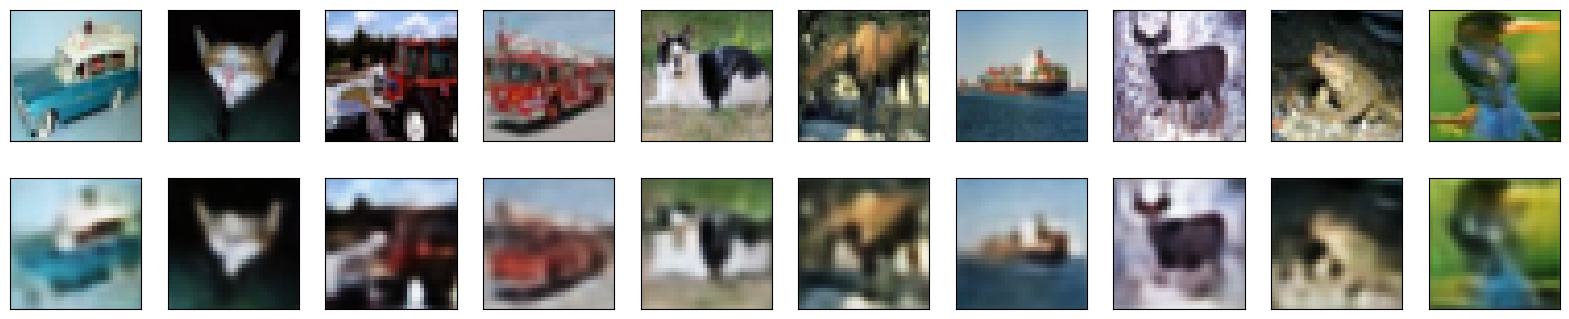

In [37]:
display(X_test, preds)

The images appear to be better with mse loss function. Maybe the best case, but a bit heavy.

# <font color= #99C8F5> **Conclusions** </font>

Using a different loss function (MSE), the output was way better than the previous ones with binary_crossentropy_loss. Though the model still has a lot of parameters, the output is acceptable, although blurry.

# <font color= #99C8F5> **Bibliography and References** </font>

[1] Krizhevsky, A. (2009). Learning Multiple Layers of Features from Tiny Images. **University of Toronto**. https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf

[2] Valdarrama, S. (2021) Convolutional autoencoder for image denoising. **Keras**. https://keras.io/examples/vision/autoencoder/

[3] Chollet, F. (2016) Building Autoencoders in Keras. **The Keras Blog**. https://blog.keras.io/building-autoencoders-in-keras.html